<a href="https://colab.research.google.com/github/mahin567/gnn-for-maleware-detection/blob/main/computer_security_gnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================================
# CELL 1: SETUP
# ====================================================================
!pip install -q unrar androguard pandas numpy scikit-learn tqdm matplotlib seaborn
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
!pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{torch.__version__}.html

import os, glob
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.data import Data

print("✅ All packages installed!")

Torch version: 2.11.0+cu128
CUDA available: True
✅ All packages installed!


In [ ]:
# ====================================================================
# CELL 2: DATASET MODE — choose "csv" or "apk"
# ====================================================================
DATA_MODE = "csv"   # "csv" or "apk"

content_dir = '/content/'

# Extract any RAR present
for fname in os.listdir(content_dir):
    if fname.lower().endswith('.rar'):
        rar_path = os.path.join(content_dir, fname)
        print(f"📦 Extracting: {rar_path}")
        os.system(f'unrar x -o+ "{rar_path}" "{content_dir}"')

df = None
apk_files, labels_found = [], []

if DATA_MODE == "csv":
    print("📄 CSV mode selected — APK mode is OFF.")

    # Use os.listdir + endswith instead of glob (avoids hidden-character issues)
    csv_candidates = [f for f in os.listdir(content_dir) if f.lower().endswith('.csv')]
    print("CSV files found:", csv_candidates)

    if not csv_candidates:
        # Recursive fallback search
        for root, dirs, files in os.walk(content_dir):
            for f in files:
                if f.lower().endswith('.csv'):
                    csv_candidates.append(os.path.join(root, f))
        print("Recursive search found:", csv_candidates)

    if not csv_candidates:
        raise FileNotFoundError(
            "❌ No CSV found. Run: for f in os.listdir('/content/'): print(repr(f))  "
            "to inspect filenames for hidden characters."
        )

    csv_name = csv_candidates[0]
    csv_path = csv_name if os.path.isabs(csv_name) or os.sep in csv_name else os.path.join(content_dir, csv_name)
    print(f"📄 Using CSV: {csv_path}")

    df = pd.read_csv(csv_path)
    print(f"✅ Loaded dataset! Shape: {df.shape}")
    print("\nLabel distribution:")
    print(df.iloc[:, -1].value_counts())

elif DATA_MODE == "apk":
    print("📱 APK mode selected — CSV mode is OFF.")
    from androguard.misc import AnalyzeAPK

    apk_files = []
    for root, dirs, files in os.walk(content_dir):
        for f in files:
            if f.lower().endswith('.apk'):
                apk_files.append(os.path.join(root, f))

    if not apk_files:
        raise FileNotFoundError("❌ No .apk files found.")
    print(f"✅ Found {len(apk_files)} APK files")

    def get_label_from_path(path):
        p = path.lower()
        if 'malware' in p or 'malicious' in p or '/mal/' in p:
            return 1
        if 'benign' in p or 'clean' in p or '/ben/' in p:
            return 0
        return None

    labels_found = [get_label_from_path(p) for p in apk_files]
    unlabeled_count = sum(1 for l in labels_found if l is None)
    print(f"Labeled: {len(apk_files) - unlabeled_count} | Unlabeled: {unlabeled_count}")
    if unlabeled_count == len(apk_files):
        print("⚠️ WARNING: No labels detected from folder names. "
              "Edit get_label_from_path() to match your dataset's structure.")

else:
    raise ValueError('DATA_MODE must be "csv" or "apk"')

📄 CSV mode selected — APK mode is OFF.
CSV files found: ['drebin_dataset.csv']
📄 Using CSV: /content/drebin_dataset.csv
✅ Loaded dataset! Shape: (15036, 216)

Label distribution:
class
B    9476
S    5560
Name: count, dtype: int64


/tmp/ipykernel_32474/2541975717.py:43: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


In [ ]:
print(df.iloc[:, -1].value_counts())

class
B    9476
S    5560
Name: count, dtype: int64


In [ ]:
# ====================================================================
# CELL 3: BEHAVIORAL ABSTRACTION LAYER + GRAPH CONSTRUCTION
# ====================================================================
api_categories = {
    'SEND_SMS':       ['sendsms', 'sendtextmessage', 'smsmanager', 'sms'],
    'NETWORK':        ['http', 'url', 'connect', 'socket', 'inet', 'wifi', 'apn'],
    'DEVICE_INFO':    ['deviceid', 'subscriberid', 'telephonymanager', 'simserial',
                        'getdeviceid', 'androidid', 'imei'],
    'FILE_ACCESS':    ['file', 'storage', 'external', 'read', 'write', 'mount'],
    'USER_IDENTITY':  ['getline1number', 'account', 'contact', 'getaccounts',
                        'subscriberinfo'],
    'PERMISSION':     ['permission'],
    'CRYPTO':         ['crypto', 'cipher', 'encrypt', 'decrypt', 'base64'],
    'PROCESS_EXEC':   ['exec', 'runtime', 'loadlibrary', 'reflect', 'dexclassloader'],
    'LOCATION':       ['location', 'gps', 'getlastknown'],
    'CALL_LOG':       ['calllog', 'phonestate', 'calling', 'dialer'],
    'SYSTEM_SERVICE': ['servicemanager', 'startservice', 'bindservice'],
    'INTENT':         ['intent', 'broadcastreceiver', 'action_boot'],
}

def abstract_feature(name):
    name_l = name.lower()
    for category, keywords in api_categories.items():
        if any(k in name_l for k in keywords):
            return category
    return 'OTHER'


graph_dataset = []

if DATA_MODE == "csv":
    feature_cols = df.columns[:-1]
    col_to_category = {col: abstract_feature(col) for col in feature_cols}
    all_categories = sorted(set(col_to_category.values()))
    cat_to_idx = {cat: i for i, cat in enumerate(all_categories)}
    NUM_CATEGORIES = len(all_categories)

    print(f"✅ Behavioral categories ({NUM_CATEGORIES}): {all_categories}")

    raw_labels = df.iloc[:, -1]
    print(f"Raw label distribution:\n{raw_labels.value_counts()}")

    if raw_labels.dtype == object:
        unique_vals = set(str(v).strip().lower() for v in raw_labels.unique())
        print(f"Unique label strings: {unique_vals}")
        positive_tokens = {'malware', '1', 'true', 's', 'malicious', 'yes'}
        label_map = {v: (1 if v in positive_tokens else 0) for v in unique_vals}
    else:
        label_map = None

    def row_to_graph(row):
        raw_label = row.iloc[-1]
        if label_map is not None:
            label = label_map[str(raw_label).strip().lower()]
        else:
            # Labels are 1-5: assume 1 = benign, 2-5 = malware families -> binary
            label = 0 if int(raw_label) == 1 else 1

        active_features = [col for col in feature_cols if row[col] == 1]

        if len(active_features) == 0:
            x = torch.zeros((1, NUM_CATEGORIES), dtype=torch.float)
            edge_index = torch.tensor([[0, 0]], dtype=torch.long).t()
            return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))

        categories = [col_to_category[f] for f in active_features]
        unique_cats = sorted(set(categories))
        node_map = {cat: i for i, cat in enumerate(unique_cats)}

        x = torch.zeros((len(unique_cats), NUM_CATEGORIES), dtype=torch.float)
        for cat, idx in node_map.items():
            x[idx, cat_to_idx[cat]] = 1.0

        edge_list = []
        for i in range(len(categories) - 1):
            src = node_map[categories[i]]
            dst = node_map[categories[i + 1]]
            edge_list.append([src, dst])

        if edge_list:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.tensor([[0, 0]], dtype=torch.long).t()

        return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))

    for idx in tqdm(range(len(df)), desc="Building graphs"):
        graph_dataset.append(row_to_graph(df.iloc[idx]))

elif DATA_MODE == "apk":
    all_categories = sorted(api_categories.keys()) + ['OTHER']
    cat_to_idx = {cat: i for i, cat in enumerate(all_categories)}
    NUM_CATEGORIES = len(all_categories)

    print(f"✅ Behavioral categories ({NUM_CATEGORIES}): {all_categories}")

    def extract_apk_categories(apk_path):
        cats = set()
        try:
            a, d, dx = AnalyzeAPK(apk_path)
            for perm in a.get_permissions():
                cats.add(abstract_feature(perm))
            for method in dx.get_methods():
                m = method.get_method()
                full_name = f"{m.get_class_name()}{m.get_name()}"
                cat = abstract_feature(full_name)
                if cat != 'OTHER':
                    cats.add(cat)
        except Exception as e:
            print(f"⚠️ Failed to analyze {apk_path}: {e}")
        return cats

    skipped = 0
    for apk_path, label in tqdm(list(zip(apk_files, labels_found)), desc="Analyzing APKs"):
        if label is None:
            skipped += 1
            continue

        label = 1 if label == 1 else 0
        cats = extract_apk_categories(apk_path)

        if len(cats) == 0:
            x = torch.zeros((1, NUM_CATEGORIES), dtype=torch.float)
            edge_index = torch.tensor([[0, 0]], dtype=torch.long).t()
            graph_dataset.append(Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long)))
            continue

        unique_cats = sorted(cats)
        x = torch.zeros((len(unique_cats), NUM_CATEGORIES), dtype=torch.float)
        for i, cat in enumerate(unique_cats):
            x[i, cat_to_idx[cat]] = 1.0

        edge_list = [[i, i + 1] for i in range(len(unique_cats) - 1)]
        if edge_list:
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.tensor([[0, 0]], dtype=torch.long).t()

        graph_dataset.append(Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long)))

    print(f"✅ Built {len(graph_dataset)} graphs from APKs ({skipped} skipped - unlabeled)")

print(f"✅ Total graphs: {len(graph_dataset)} | Feature dim per node = {NUM_CATEGORIES}")

# Validation check
_labels_check = [g.y.item() for g in graph_dataset]
print(f"Label range: min={min(_labels_check)}, max={max(_labels_check)}, unique={set(_labels_check)}")
assert all(l in (0, 1) for l in _labels_check), "❌ Found label outside {0,1}!"

✅ Behavioral categories (12): ['CALL_LOG', 'CRYPTO', 'DEVICE_INFO', 'FILE_ACCESS', 'INTENT', 'LOCATION', 'NETWORK', 'OTHER', 'PROCESS_EXEC', 'SEND_SMS', 'SYSTEM_SERVICE', 'USER_IDENTITY']
Raw label distribution:
class
B    9476
S    5560
Name: count, dtype: int64
Unique label strings: {'s', 'b'}


Building graphs: 100%|██████████| 15036/15036 [00:16<00:00, 885.28it/s] 

✅ Total graphs: 15036 | Feature dim per node = 12
Label range: min=0, max=1, unique={0, 1}


In [ ]:
labels_list = [g.y.item() for g in graph_dataset]
print("Unique labels:", set(labels_list))
print("Min:", min(labels_list), "Max:", max(labels_list))

Unique labels: {0, 1}
Min: 0 Max: 1


Class distribution: Counter({0: 9476, 1: 5560})
Train labels: Counter({0: 7580, 1: 4448})
Test labels:  Counter({0: 1896, 1: 1112})
Train: 12028 | Test: 3008
Class weights → Benign: 0.7934 | Malware: 1.3522
✅ LightGNN ready — total parameters: 434
Epoch 01 | Loss: 0.3081 | Test Acc: 0.9092
Epoch 05 | Loss: 0.1795 | Test Acc: 0.9215
Epoch 10 | Loss: 0.1580 | Test Acc: 0.9378
Epoch 15 | Loss: 0.1485 | Test Acc: 0.9405
Epoch 20 | Loss: 0.1416 | Test Acc: 0.9405
Epoch 25 | Loss: 0.1377 | Test Acc: 0.9441
Epoch 30 | Loss: 0.1334 | Test Acc: 0.9488


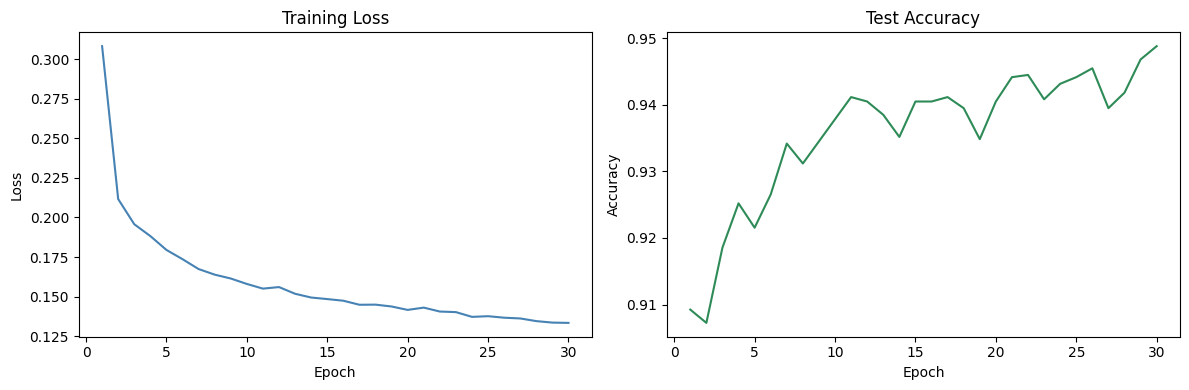


Confusion Matrix:
 [[1817   79]
 [  75 1037]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96      1896
     Malware       0.93      0.93      0.93      1112

    accuracy                           0.95      3008
   macro avg       0.94      0.95      0.95      3008
weighted avg       0.95      0.95      0.95      3008



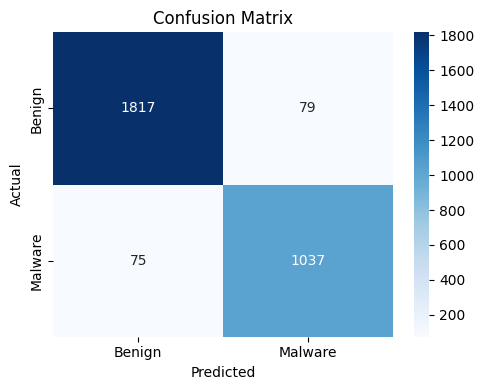

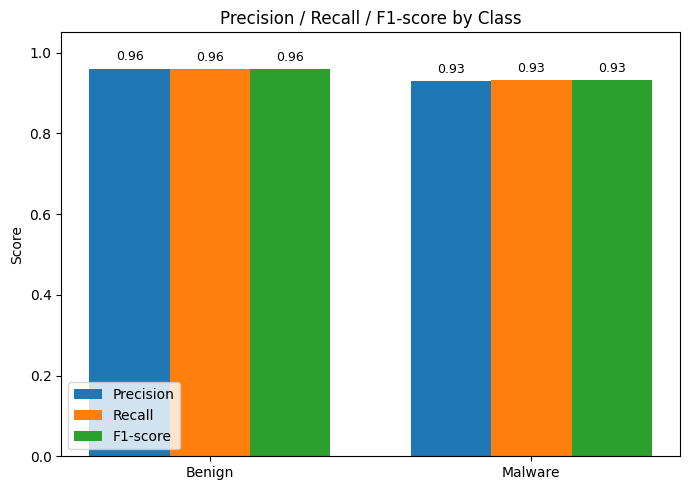

In [ ]:
# ====================================================================
# CELL 4: LIGHTWEIGHT GNN MODEL + TRAINING + CONFUSION MATRIX (FIXED)
# ====================================================================
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

labels_list = [g.y.item() for g in graph_dataset]
label_counts = Counter(labels_list)
print("Class distribution:", label_counts)

strat = labels_list if len(set(labels_list)) > 1 else None
train_data, test_data = train_test_split(graph_dataset, test_size=0.2, random_state=42, stratify=strat)

train_labels = [g.y.item() for g in train_data]
test_labels  = [g.y.item() for g in test_data]
print("Train labels:", Counter(train_labels))
print("Test labels: ", Counter(test_labels))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"Train: {len(train_data)} | Test: {len(test_data)}")


# ── Weighted loss to handle class imbalance ──────────────────────────
total = len(labels_list)
num_classes = 2
weight_benign  = total / (num_classes * label_counts[0]) if label_counts[0] > 0 else 1.0
weight_malware = total / (num_classes * label_counts[1]) if label_counts[1] > 0 else 1.0
class_weights  = torch.tensor([weight_benign, weight_malware], dtype=torch.float).to(device)
print(f"Class weights → Benign: {weight_benign:.4f} | Malware: {weight_malware:.4f}")


class LightGNN(torch.nn.Module):
    """Lightweight, interpretable GNN over behavioral API categories."""
    def __init__(self, num_node_features, hidden_dim=16, num_classes=2):
        super().__init__()
        self.conv1 = GraphConv(num_node_features, hidden_dim)
        self.lin   = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin(x)
        return x


model     = LightGNN(num_node_features=NUM_CATEGORIES, hidden_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)   # weighted loss

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ LightGNN ready — total parameters: {total_params}")


def train_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_data)


@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch.x, batch.edge_index, batch.batch)
        pred  = out.argmax(dim=1)
        preds.extend(pred.cpu().numpy())
        labels.extend(batch.y.cpu().numpy())
    return labels, preds


EPOCHS = 30
train_losses, test_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch()
    labels, preds = evaluate(test_loader)
    acc  = accuracy_score(labels, preds)
    train_losses.append(loss)
    test_accuracies.append(acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Test Acc: {acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), train_losses,    color='steelblue')
axes[0].set_title("Training Loss");   axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].plot(range(1, EPOCHS + 1), test_accuracies, color='seagreen')
axes[1].set_title("Test Accuracy");   axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


# ── Evaluation with explicit labels=[0,1] to handle single-class edge case ──
final_labels, final_preds = evaluate(test_loader)

cm = confusion_matrix(final_labels, final_preds, labels=[0, 1])
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:")
print(classification_report(final_labels, final_preds,
                            labels=[0, 1],
                            target_names=['Benign', 'Malware'],
                            zero_division=0))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


precision, recall, f1, support = precision_recall_fscore_support(
    final_labels, final_preds, labels=[0, 1], zero_division=0
)
classes = ['Benign', 'Malware']
metrics = {'Precision': precision, 'Recall': recall, 'F1-score': f1}
x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
for i, (name, vals) in enumerate(metrics.items()):
    ax.bar(x + i * width, vals, width, label=name)
ax.set_xticks(x + width); ax.set_xticklabels(classes)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1-score by Class')
ax.legend()
for i, (name, vals) in enumerate(metrics.items()):
    for j, v in enumerate(vals):
        ax.text(j + i * width, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('precision_recall_f1.png', dpi=150)
plt.show()


Behavioral Category Importance (avg confidence drop when removed):
      Category  Importance
      SEND_SMS    0.363120
   DEVICE_INFO    0.171313
   FILE_ACCESS    0.109331
      LOCATION    0.063955
  PROCESS_EXEC    0.059465
       NETWORK    0.042929
        INTENT    0.023916
        CRYPTO    0.005153
      CALL_LOG    0.000000
 USER_IDENTITY   -0.003064
SYSTEM_SERVICE   -0.005063
         OTHER   -0.032850


/tmp/ipykernel_32474/3250278742.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Category', palette='viridis')


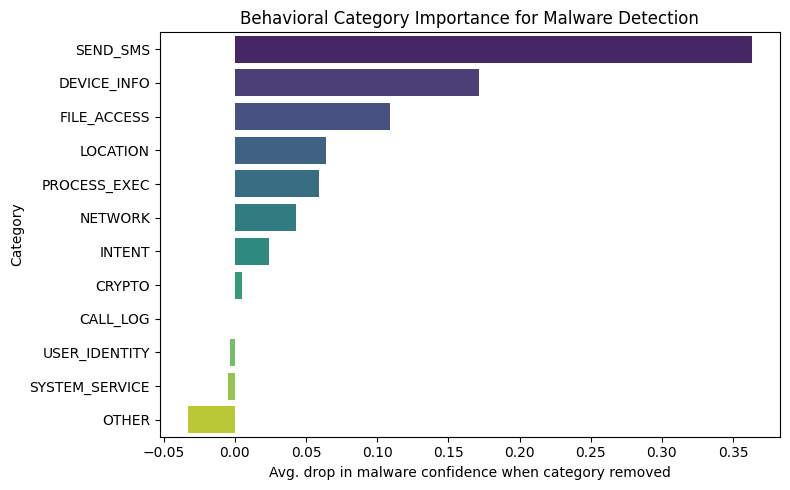

In [ ]:
# ====================================================================
# CELL 5: INTERPRETABILITY — CATEGORY IMPORTANCE (GNN-LRP-style)
# ====================================================================
model.eval()
malware_samples = [g for g in test_data if g.y.item() == 1][:100]

category_importance = np.zeros(NUM_CATEGORIES)

if malware_samples:
    with torch.no_grad():
        for g in malware_samples:
            g = g.to(device)
            batch = torch.zeros(g.x.shape[0], dtype=torch.long, device=device)

            base_out = model(g.x, g.edge_index, batch)
            base_score = F.softmax(base_out, dim=1)[0, 1].item()

            for cat_idx in range(NUM_CATEGORIES):
                x_occluded = g.x.clone()
                x_occluded[:, cat_idx] = 0.0
                out = model(x_occluded, g.edge_index, batch)
                score = F.softmax(out, dim=1)[0, 1].item()
                category_importance[cat_idx] += (base_score - score)

    category_importance /= len(malware_samples)

    imp_df = pd.DataFrame({
        'Category': all_categories,
        'Importance': category_importance
    }).sort_values('Importance', ascending=False)

    print("\nBehavioral Category Importance (avg confidence drop when removed):")
    print(imp_df.to_string(index=False))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=imp_df, x='Importance', y='Category', palette='viridis')
    plt.title('Behavioral Category Importance for Malware Detection')
    plt.xlabel('Avg. drop in malware confidence when category removed')
    plt.tight_layout()
    plt.savefig('category_importance.png', dpi=150)
    plt.show()
else:
    print("⚠️ No malware samples in test set — skipping interpretability analysis.")

In [ ]:
# ====================================================================
# CELL 6: RESULTS SUMMARY TABLE
# ====================================================================
final_acc = accuracy_score(final_labels, final_preds)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Malware)', 'Recall (Malware)',
               'F1-score (Malware)', 'Total Parameters', 'Behavioral Categories', 'Data Mode'],
    'Value': [f"{final_acc:.4f}", f"{precision[1]:.4f}", f"{recall[1]:.4f}",
              f"{f1[1]:.4f}", str(total_params), str(NUM_CATEGORIES), DATA_MODE]
})
print("\n=== Results Summary ===")
print(summary.to_string(index=False))


=== Results Summary ===
               Metric  Value
             Accuracy 0.9488
  Precision (Malware) 0.9292
     Recall (Malware) 0.9326
   F1-score (Malware) 0.9309
     Total Parameters    434
Behavioral Categories     12
            Data Mode    csv
